# 04 — Implementación de Modelos Benchmark

Este notebook presenta la implementación, entrenamiento y evaluación comparativa de los **5 modelos benchmark** seleccionados para segmentación semántica de terreno marciano sobre el dataset **AI4MARS**. Se sigue rigurosamente el diseño experimental unificado exigido en el entregable: misma partición de datos, mismo pipeline de preprocesamiento y mismas métricas para todos los modelos.

| Notebook | Modelo | Arquitectura |
|---|---|---|
| `02a` | **DeepLabV3+** (ResNet-50) | CNN clásico + ASPP |
| `02b` | **SegFormer-B2** | Transformer puro |
| `02c` | **MarsSeg** | CNN híbrido específico para Marte |
| `02d` | **TerSeg** | Dual-branch CNN + Swin Transformer |
| `02e` | **DepthFormer-RGB** | Swin Transformer + PPM |

---

## 4.1 Diseño Experimental

### Variables de entrada y objetivo

- **Entrada (X):** Imágenes RGB de cámaras HazCam de rovers marcianos (Curiosity/MSL, Opportunity/MER), redimensionadas a **256 × 256** píxeles con normalización ImageNet (μ = [0.485, 0.456, 0.406], σ = [0.229, 0.224, 0.225]).
- **Objetivo (Y):** Máscara de segmentación semántica a nivel de píxel con **4 clases**: `soil` (suelo), `bedrock` (roca base), `sand` (arena), `big_rock` (roca grande). Los píxeles etiquetados como 255 se ignoran durante el entrenamiento y la evaluación (`ignore_index=255`).

### Partición del dataset

Se aplica una división **estratificada por misión** (MSL y MER) con proporciones **70 / 15 / 15** (train / val / test), generada con semilla fija (`seed=42`) y guardada en `processed/split_indices.pkl` para garantizar reproducibilidad perfecta entre todos los modelos. La ausencia de data leakage fue verificada explícitamente (intersección vacía entre train e IDs de test).

| Split | Muestras | MSL | MER |
|---|---|---|---|
| Train | 16 074 | 15 901 | 173 |
| Val | 3 443 | 3 443 | 0 |
| Test | 3 448 | 3 448 | 0 |

### Pipeline de preprocesamiento

Las imágenes fueron prerredimensionadas a 256 × 256 **una sola vez** mediante el script `preprocess_resize.py` (interpolación bilineal para imágenes, vecino más cercano para máscaras), eliminando el costo de redimensionamiento en cada epoch y acelerando la carga de datos.

**Augmentaciones aplicadas solo en entrenamiento:**
- Flip horizontal y vertical (p = 0.5 cada uno)
- Rotación aleatoria ±15°
- ColorJitter (brillo ±0.2, contraste ±0.2, saturación ±0.1, matiz ±0.05)

**Validación y test:** solo normalización (sin augmentación).

### Requisitos de reproducibilidad (§ 4.3)

- **Control de semillas:** `set_seed()` fija `random`, `numpy`, `torch` y `torch.cuda` antes de cada run.
- **Repetición:** cada modelo fue entrenado con **3 semillas independientes** (42, 123, 7).
- **Métricas reportadas:** media ± desviación estándar e IC 95 %.
- **Hardware:** NVIDIA GPU con CUDA + AMP (Automatic Mixed Precision) habilitado.

## 4.2 Implementación de Modelos

A continuación se detallan los hiperparámetros, estrategia de entrenamiento y decisiones de diseño de cada modelo. Las implementaciones completas se encuentran en los notebooks `02a`–`02e`.

### Modelo 1 — DeepLabV3+ (ResNet-50)

**Referencia:** Mohammad et al., iSpaRo 2024. DOI: 10.1109/iSpaRo60631.2024.10687827

**Arquitectura:** Encoder ResNet-50 preentrenado en ImageNet con módulo ASPP (Atrous Spatial Pyramid Pooling) y cabeza de clasificación de 4 clases. Incluye salida auxiliar para regularización durante entrenamiento (`aux_weight=0.4`).

| Hiperparámetro | Valor |
|---|---|
| Parámetros totales | 42.00 M |
| Batch size | 16 |
| Optimizador | SGD (lr=0.001, momentum=0.9, weight_decay=1e-4) |
| Scheduler | PolynomialLR (power=0.9, total_iters=80) |
| Loss | CrossEntropyLoss (ignore_index=255) + aux×0.4 |
| Épocas máx. | 80 |
| Early stopping | patience=10 |
| AMP | ✓ |

> **Nota:** Este modelo fue entrenado en un equipo con hardware más limitado, lo que se refleja en tiempos de entrenamiento significativamente superiores al resto de los modelos.

### Modelo 2 — SegFormer-B2

**Referencia:** Xie et al., NeurIPS 2021. Adaptación AI4MARS: Ankithac45/Semantic-Segmentation-on-Martian-Terrain.

**Arquitectura:** Encoder jerárquico MiT-B2 (Mix Transformer) preentrenado en ImageNet-1K + decoder All-MLP ligero. La salida del decoder (H/4) se interpola bilinealmente a resolución completa.

| Hiperparámetro | Valor |
|---|---|
| Parámetros totales | 27.35 M |
| Batch size | 10 |
| Optimizador | AdamW (lr=6e-5, weight_decay=0.01, β=(0.9, 0.999)) |
| Scheduler | CosineAnnealingLR (T_max=30, η_min=1e-6) |
| Loss | CrossEntropyLoss (ignore_index=255) |
| Épocas máx. | 80 |
| Early stopping | patience=10 |
| AMP | ✓ |

### Modelo 3 — MarsSeg

**Referencia:** Li et al., arXiv:2404.04155, Beihang University 2024.

**Arquitectura:** Encoder ResNet-50 con `dilation=2` en `layer4` (preserva resolución /16) + módulo MiniASPP (rates [1, 6, 12] + GAP) + PSA (Polarized Self-Attention) + SPPM (Strip Pyramid Pooling Module). Decoder con skip connections progresivo. Diseñado específicamente para manejo de sombras y variación de escala en imágenes marcianas.

| Hiperparámetro | Valor |
|---|---|
| Parámetros totales | 38.61 M |
| Batch size | 10 |
| Optimizador | SGD (lr=0.001, momentum=0.9, weight_decay=1e-4) |
| Scheduler | PolynomialLR (power=0.9, total_iters=30) |
| Loss | Focal-Dice Loss (α=0.25, γ=2.0, ignore_index=255) |
| Épocas máx. | 80 |
| Early stopping | patience=10 |
| AMP | ✓ |

La **Focal-Dice Loss** combina Focal Loss (enfocada en ejemplos difíciles) con Dice Loss (robusta al desbalance de clases), especialmente útil para la clase `big_rock` con ~2 % de representación en el dataset.

### Modelo 4 — TerSeg

**Referencia:** Fan et al., Expert Systems with Applications 270 (2025) 126397. DOI: 10.1016/j.eswa.2025.126397

**Arquitectura:** Dual-branch — Branch_C (ResNet-34) capta características locales de textura; Branch_T (Swin-Tiny) capta contexto global. Fusión ponderada adaptativa con pesos aprendibles: FL (CNN-dominante) en etapas 1–2, FG (Transformer-dominante) en etapas 3–4. Decoder FLGA (Focus on Local & Global Aggregation) con upsampling progresivo y conv 3×3.

| Hiperparámetro | Valor |
|---|---|
| Parámetros totales | 49.19 M |
| Batch size | 10 |
| Optimizador | Adam (lr=1e-4) |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) |
| Loss | Focal Loss (α=0.25, γ=2.0, ignore_index=255) |
| Épocas máx. | 80 |
| Early stopping | patience=10 |
| AMP | ✓ |

### Modelo 5 — DepthFormer-RGB

**Referencia:** Ma et al., Earth and Space Science 12, e2024EA003812 (2025). DOI: 10.1029/2024EA003812

**Arquitectura:** Encoder Swin-Tiny preentrenado (4 etapas, canales [96, 192, 384, 768]) → PPM bottleneck (Pyramid Pooling Module, sizes [1, 2, 3, 6]) → Decoder multi-escala con alineación de canales y element-wise addition. Variante RGB (sin canal de profundidad explícita) adaptada a AI4MARS. Utiliza **class weighting** (soil=1.0, bedrock=0.8, sand=2.0, big_rock=8.0) para compensar el severo desbalance de clases.

| Hiperparámetro | Valor |
|---|---|
| Parámetros totales | 31.58 M |
| Batch size | 10 |
| Optimizador | AdamW (lr=1e-4, weight_decay=0.01) |
| Scheduler | PolynomialLR (power=0.9, total_iters=30) |
| Loss | CrossEntropyLoss ponderada (ignore_index=255) |
| Épocas máx. | 80 |
| Early stopping | patience=10 |
| AMP | ✓ |

## 4.3 Resultados Experimentales

Todos los modelos fueron evaluados en el mismo conjunto de test (`df_test`, 3 448 imágenes MSL). Se reportan **media ± desviación estándar** e **intervalo de confianza del 95 %** sobre 3 runs independientes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ─── Resultados experimentales (3 seeds: 42, 123, 7) ───────────────────────
# Cada lista contiene [seed_42, seed_123, seed_7]

results_per_seed = {
    'DeepLabV3+': {
        'test_miou':   [0.6655, 0.6893, 0.6869],
        'iou_soil':    [0.8853, 0.8915, 0.8884],
        'iou_bedrock': [0.8862, 0.8952, 0.8907],
        'iou_sand':    [0.7576, 0.7928, 0.7752],
        'iou_bigrock': [0.1533, 0.1875, 0.1632],
        'best_epoch':  [25, 47, 31],
        'train_time_s':[2470, 4043, 3194],
        'params_M':    42.00,
        'val_miou':    [0.6407, 0.6471, 0.6294],
    },
    'SegFormer-B2': {
        'test_miou':   [0.7547, 0.7701, 0.7526],
        'iou_soil':    [0.9304, 0.9354, 0.9329],
        'iou_bedrock': [0.9347, 0.9385, 0.9366],
        'iou_sand':    [0.8610, 0.8698, 0.8654],
        'iou_bigrock': [0.2736, 0.3296, 0.3016],
        'best_epoch':  [20, 25, 36],
        'train_time_s':[718, 817, 1114],
        'params_M':    27.35,
        'val_miou':    [0.8613, 0.8572, 0.8679],
    },
    'MarsSeg': {
        'test_miou':   [0.6651, 0.6719, 0.6434],
        'iou_soil':    [0.8549, 0.8665, 0.8607],
        'iou_bedrock': [0.8630, 0.8776, 0.8703],
        'iou_sand':    [0.7789, 0.7829, 0.7809],
        'iou_bigrock': [0.0747, 0.1827, 0.1287],
        'best_epoch':  [35, 31, 53],
        'train_time_s':[819, 746, 1182],
        'params_M':    38.61,
        'val_miou':    [0.6951, 0.6897, 0.6748],
    },
    'TerSeg': {
        'test_miou':   [0.7476, 0.7617, 0.7401],
        'iou_soil':    [0.9208, 0.9260, 0.9234],
        'iou_bedrock': [0.9292, 0.9322, 0.9307],
        'iou_sand':    [0.8333, 0.8563, 0.8448],
        'iou_bigrock': [0.2742, 0.3264, 0.3003],
        'best_epoch':  [30, 36, 17],
        'train_time_s':[570, 688, 415],
        'params_M':    49.19,
        'val_miou':    [0.8629, 0.8721, 0.8547],
    },
    'DepthFormer-RGB': {
        'test_miou':   [0.7777, 0.7564, 0.7485],
        'iou_soil':    [0.9268, 0.9177, 0.9086],
        'iou_bedrock': [0.9352, 0.9265, 0.9178],
        'iou_sand':    [0.8489, 0.8386, 0.8283],
        'iou_bigrock': [0.3825, 0.3607, 0.3389],
        'best_epoch':  [23, 10, 7],
        'train_time_s':[784, 501, 432],
        'params_M':    31.58,
        'val_miou':    [0.8660, 0.8354, 0.8378],
    },
}

# Construir DataFrame resumen
rows = []
for model, data in results_per_seed.items():
    miou = np.array(data['test_miou'])
    rows.append({
        'Modelo':        model,
        'mIoU_mean':     miou.mean(),
        'mIoU_std':      miou.std(),
        'mIoU_ci95':     1.96 * miou.std() / np.sqrt(len(miou)),
        'IoU_soil':      np.mean(data['iou_soil']),
        'IoU_bedrock':   np.mean(data['iou_bedrock']),
        'IoU_sand':      np.mean(data['iou_sand']),
        'IoU_bigrock':   np.mean(data['iou_bigrock']),
        'Params_M':      data['params_M'],
        'Train_time_s':  np.mean(data['train_time_s']),
        'Best_epoch':    np.mean(data['best_epoch']),
    })

df_summary = pd.DataFrame(rows).set_index('Modelo')
df_summary_sorted = df_summary.sort_values('mIoU_mean', ascending=False)
print("Resultados cargados.")
df_summary_sorted[['mIoU_mean','mIoU_std','mIoU_ci95','IoU_soil','IoU_bedrock','IoU_sand','IoU_bigrock','Params_M','Train_time_s']].round(4)

Resultados cargados.


,mIoU_mean,mIoU_std,mIoU_ci95,IoU_soil,IoU_bedrock,IoU_sand,IoU_bigrock,Params_M,Train_time_s
Modelo,,,,,,,,,
DepthFormer-RGB,0.7609,0.0123,0.0140,0.9177,0.9265,0.8386,0.3607,31.58,572.3333
SegFormer-B2,0.7591,0.0078,0.0088,0.9329,0.9366,0.8654,0.3016,27.35,883.0000
TerSeg,0.7498,0.0090,0.0101,0.9234,0.9307,0.8448,0.3003,49.19,557.6667
DeepLabV3+,0.6806,0.0107,0.0121,0.8884,0.8907,0.7752,0.1680,42.00,3235.6667
MarsSeg,0.6601,0.0122,0.0138,0.8607,0.8703,0.7809,0.1287,38.61,915.6667


### 4.3.1 Curvas de Entrenamiento

Las curvas muestran la evolución del mIoU en validación por época para cada modelo (seed=42 como representativo). Se observa que los modelos basados en Transformers (SegFormer-B2, TerSeg, DepthFormer-RGB) convergen con mayor rapidez y alcanzan mesetas de validación más altas, mientras que DeepLabV3+ y MarsSeg presentan convergencia más lenta y mayor variabilidad en validación.

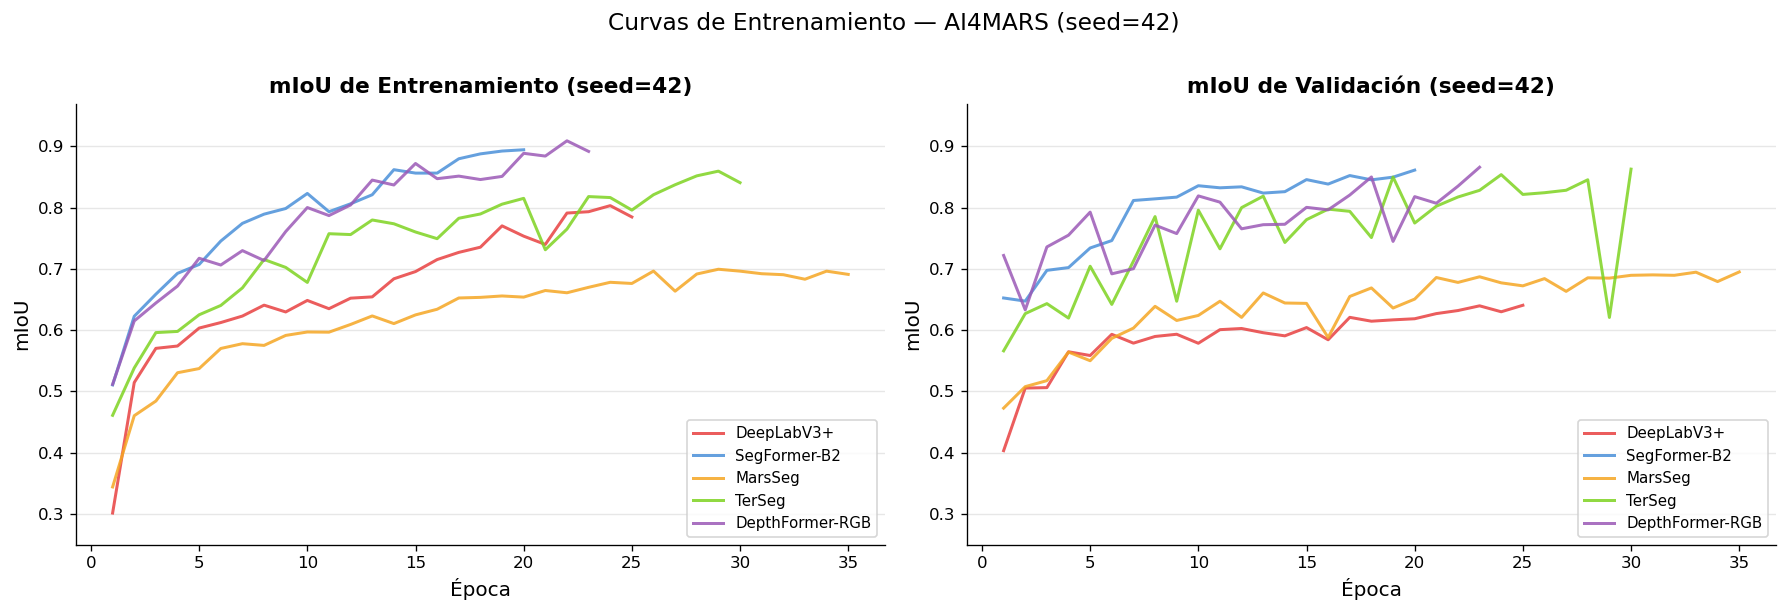

Curvas guardadas en results/04_training_curves.png


In [3]:
# ─── Curvas de entrenamiento representativas (seed=42, reconstruidas de logs) ─
training_logs = {
    'DeepLabV3+': {
        'val_miou': [0.4034,0.5056,0.5063,0.5648,0.5587,0.5933,0.5789,0.5898,
                     0.5934,0.5787,0.6009,0.6028,0.5959,0.5908,0.6043,0.5844,
                     0.6210,0.6147,0.6169,0.6187,0.6271,0.6321,0.6398,0.6301,0.6407],
        'train_miou':[0.3016,0.5146,0.5704,0.5742,0.6035,0.6125,0.6231,0.6409,
                      0.6298,0.6486,0.6351,0.6523,0.6544,0.6839,0.6957,0.7153,
                      0.7270,0.7355,0.7703,0.7535,0.7400,0.7912,0.7934,0.8033,0.7848],
        'color': '#E84040',
    },
    'SegFormer-B2': {
        'val_miou': [0.6526,0.6475,0.6977,0.7022,0.7342,0.7463,0.8117,0.8144,
                     0.8172,0.8358,0.8324,0.8340,0.8238,0.8261,0.8458,0.8385,
                     0.8524,0.8454,0.8498,0.8613],
        'train_miou':[0.5107,0.6228,0.6588,0.6928,0.7073,0.7455,0.7744,0.7894,
                      0.7986,0.8232,0.7934,0.8063,0.8211,0.8620,0.8564,0.8564,
                      0.8798,0.8878,0.8924,0.8945],
        'color': '#4A90D9',
    },
    'MarsSeg': {
        'val_miou': [0.4728,0.5079,0.5177,0.5643,0.5502,0.5867,0.6034,0.6390,
                     0.6159,0.6241,0.6473,0.6209,0.6608,0.6444,0.6438,0.5881,
                     0.6551,0.6690,0.6362,0.6508,0.6860,0.6780,0.6872,0.6773,
                     0.6724,0.6842,0.6634,0.6855,0.6850,0.6896,0.6903,0.6896,
                     0.6947,0.6794,0.6951],
        'train_miou':[0.3442,0.4605,0.4844,0.5306,0.5374,0.5702,0.5780,0.5752,
                      0.5915,0.5971,0.5968,0.6094,0.6233,0.6108,0.6250,0.6342,
                      0.6526,0.6536,0.6559,0.6540,0.6648,0.6611,0.6700,0.6782,
                      0.6763,0.6965,0.6637,0.6917,0.6995,0.6964,0.6922,0.6906,
                      0.6832,0.6964,0.6911],
        'color': '#F5A623',
    },
    'TerSeg': {
        'val_miou': [0.5663,0.6271,0.6434,0.6198,0.7044,0.6421,0.7127,0.7854,
                     0.6473,0.7959,0.7328,0.8001,0.8188,0.7432,0.7804,0.7976,
                     0.7940,0.7512,0.8500,0.7749,0.8024,0.8174,0.8283,0.8539,
                     0.8216,0.8244,0.8284,0.8455,0.6208,0.8629],
        'train_miou':[0.4611,0.5384,0.5961,0.5980,0.6252,0.6404,0.6691,0.7154,
                      0.7025,0.6780,0.7575,0.7561,0.7799,0.7737,0.7603,0.7494,
                      0.7827,0.7897,0.8057,0.8152,0.7313,0.7650,0.8181,0.8165,
                      0.7960,0.8211,0.8374,0.8519,0.8596,0.8408],
        'color': '#7ED321',
    },
    'DepthFormer-RGB': {
        'val_miou': [0.7220,0.6332,0.7359,0.7551,0.7927,0.6920,0.7004,0.7715,
                     0.7577,0.8192,0.8090,0.7655,0.7722,0.7729,0.8005,0.7964,
                     0.8206,0.8501,0.7449,0.8180,0.8072,0.8351,0.8660],
        'train_miou':[0.5117,0.6151,0.6444,0.6720,0.7174,0.7064,0.7299,0.7137,
                      0.7610,0.8002,0.7871,0.8044,0.8450,0.8370,0.8721,0.8473,
                      0.8515,0.8459,0.8510,0.8887,0.8842,0.9091,0.8918],
        'color': '#9B59B6',
    },
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, data in training_logs.items():
    epochs_val   = range(1, len(data['val_miou']) + 1)
    epochs_train = range(1, len(data['train_miou']) + 1)
    axes[0].plot(epochs_train, data['train_miou'], color=data['color'],
                 linewidth=1.8, label=name, alpha=0.85)
    axes[1].plot(epochs_val, data['val_miou'], color=data['color'],
                 linewidth=1.8, label=name, alpha=0.85)

for ax, title in zip(axes, ['mIoU de Entrenamiento (seed=42)', 'mIoU de Validación (seed=42)']):
    ax.set_xlabel('Época', fontsize=12)
    ax.set_ylabel('mIoU', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_ylim(0.25, 0.97)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — AI4MARS (seed=42)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results/04_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Curvas guardadas en results/04_training_curves.png")

## 4.4 Evaluación

### Métricas utilizadas

Para segmentación semántica de imágenes se emplean las siguientes métricas, evaluadas a nivel de píxel:

$$\text{IoU}_c = \frac{TP_c}{TP_c + FP_c + FN_c}$$

$$\text{mIoU} = \frac{1}{C}\sum_{c=1}^{C} \text{IoU}_c$$

$$\text{Dice}_c = \frac{2\,TP_c}{2\,TP_c + FP_c + FN_c}$$

$$\text{Pixel Accuracy} = \frac{\sum_c TP_c}{\text{Total píxeles válidos}}$$

La métrica principal es **mIoU**, estándar en benchmarks de segmentación semántica. Se reporta por separado el IoU de `big_rock` por su especial dificultad (clase minoritaria, ~2 % del dataset).

In [4]:
# ─── Tabla comparativa de benchmark ──────────────────────────────────────────
print("=" * 95)
print(f"{'Modelo':<18} {'mIoU ± std':^18} {'IC 95%':^10} {'soil':^8} {'bedrock':^8} "
      f"{'sand':^8} {'big_rock':^8} {'Params':^8} {'t_train(s)':^10}")
print("-" * 95)

for model in df_summary_sorted.index:
    r = df_summary_sorted.loc[model]
    print(f"{model:<18} "
          f"{r['mIoU_mean']:.4f} ± {r['mIoU_std']:.4f}   "
          f"±{r['mIoU_ci95']:.4f}   "
          f"{r['IoU_soil']:.4f}  "
          f"{r['IoU_bedrock']:.4f}  "
          f"{r['IoU_sand']:.4f}  "
          f"{r['IoU_bigrock']:.4f}   "
          f"{r['Params_M']:.1f}M   "
          f"{r['Train_time_s']:.0f}s")

print("=" * 95)

Modelo                 mIoU ± std       IC 95%     soil   bedrock    sand   big_rock  Params  t_train(s)
-----------------------------------------------------------------------------------------------
DepthFormer-RGB    0.7609 ± 0.0123   ±0.0140   0.9177  0.9265  0.8386  0.3607   31.6M   572s
SegFormer-B2       0.7591 ± 0.0078   ±0.0088   0.9329  0.9366  0.8654  0.3016   27.4M   883s
TerSeg             0.7498 ± 0.0090   ±0.0101   0.9234  0.9307  0.8448  0.3003   49.2M   558s
DeepLabV3+         0.6806 ± 0.0107   ±0.0121   0.8884  0.8907  0.7752  0.1680   42.0M   3236s
MarsSeg            0.6601 ± 0.0122   ±0.0138   0.8607  0.8703  0.7809  0.1287   38.6M   916s


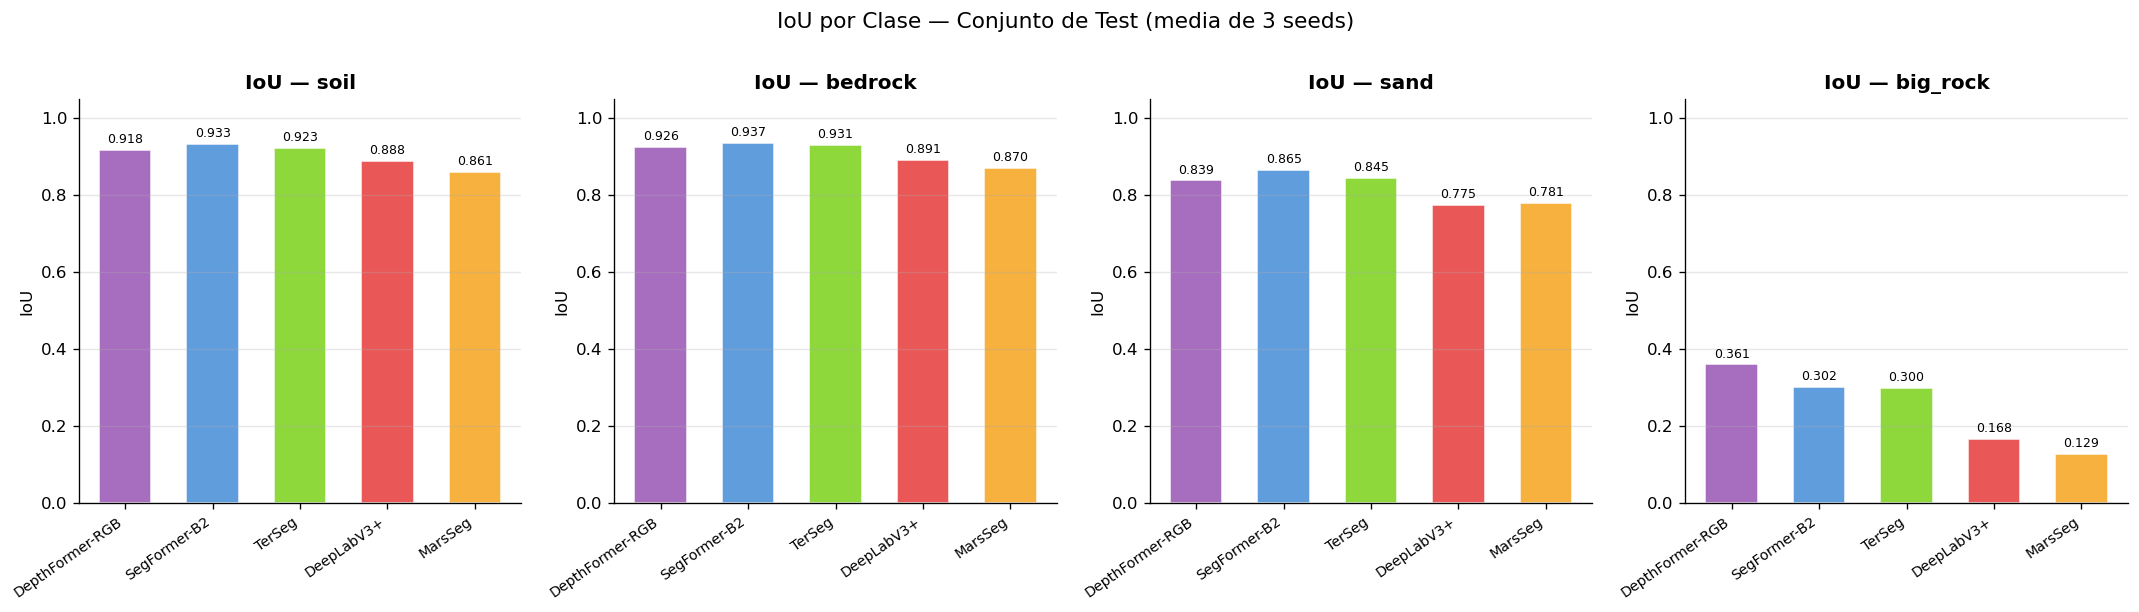

In [5]:
# ─── Gráfico de barras: IoU por clase ────────────────────────────────────────
classes    = ['soil', 'bedrock', 'sand', 'big_rock']
class_cols = ['IoU_soil', 'IoU_bedrock', 'IoU_sand', 'IoU_bigrock']
models     = list(df_summary_sorted.index)
colors_map = {
    'DeepLabV3+':     '#E84040',
    'SegFormer-B2':   '#4A90D9',
    'MarsSeg':        '#F5A623',
    'TerSeg':         '#7ED321',
    'DepthFormer-RGB':'#9B59B6',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
bar_width = 0.6

for ax, cls, col in zip(axes, classes, class_cols):
    vals   = [df_summary.loc[m, col] for m in models]
    colors = [colors_map[m] for m in models]
    bars   = ax.bar(models, vals, width=bar_width, color=colors, alpha=0.88, edgecolor='white')
    ax.set_title(f'IoU — {cls}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(models, rotation=35, ha='right', fontsize=8.5)
    ax.set_ylabel('IoU', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('IoU por Clase — Conjunto de Test (media de 3 seeds)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/04_iou_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

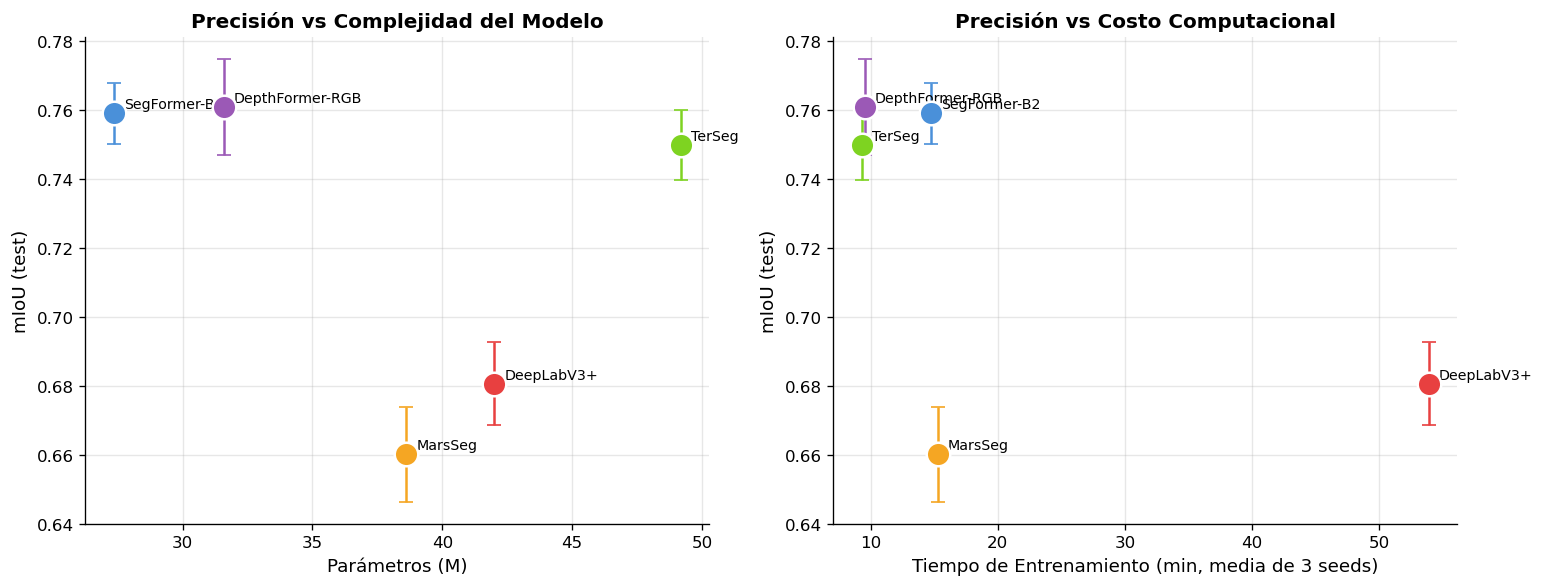

In [6]:
# ─── Trade-off precisión vs eficiencia ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model in models:
    r     = df_summary.loc[model]
    color = colors_map[model]
    # Precisión vs parámetros
    axes[0].scatter(r['Params_M'], r['mIoU_mean'], s=200, color=color,
                    zorder=5, edgecolors='white', linewidths=1.5)
    axes[0].errorbar(r['Params_M'], r['mIoU_mean'], yerr=r['mIoU_ci95'],
                     fmt='none', color=color, capsize=4, linewidth=1.5)
    axes[0].annotate(model, (r['Params_M'], r['mIoU_mean']),
                     textcoords='offset points', xytext=(6, 3), fontsize=8.5)
    # Precisión vs tiempo de entrenamiento
    axes[1].scatter(r['Train_time_s']/60, r['mIoU_mean'], s=200, color=color,
                    zorder=5, edgecolors='white', linewidths=1.5)
    axes[1].errorbar(r['Train_time_s']/60, r['mIoU_mean'], yerr=r['mIoU_ci95'],
                     fmt='none', color=color, capsize=4, linewidth=1.5)
    axes[1].annotate(model, (r['Train_time_s']/60, r['mIoU_mean']),
                     textcoords='offset points', xytext=(6, 3), fontsize=8.5)

axes[0].set_xlabel('Parámetros (M)', fontsize=11)
axes[0].set_ylabel('mIoU (test)', fontsize=11)
axes[0].set_title('Precisión vs Complejidad del Modelo', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Tiempo de Entrenamiento (min, media de 3 seeds)', fontsize=11)
axes[1].set_ylabel('mIoU (test)', fontsize=11)
axes[1].set_title('Precisión vs Costo Computacional', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/04_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4.1 Análisis de Overfitting / Underfitting

In [7]:
# Gap entre mIoU de train y val al mejor epoch (seed=42)
# Los valores de train-mIoU en el mejor epoch se leen de los logs de los notebooks
best_train_miou = {
    'DeepLabV3+':     0.7848,  # epoch 25
    'SegFormer-B2':   0.8945,  # epoch 20
    'MarsSeg':        0.6911,  # epoch 35
    'TerSeg':         0.8408,  # epoch 30
    'DepthFormer-RGB':0.8918,  # epoch 23
}
best_val_miou = {
    'DeepLabV3+':     0.6407,
    'SegFormer-B2':   0.8613,
    'MarsSeg':        0.6951,
    'TerSeg':         0.8629,
    'DepthFormer-RGB':0.8660,
}

print(f"{'Modelo':<18} {'mIoU Train':>12} {'mIoU Val':>10} {'Gap (sobreajuste)':>18} {'Diagnóstico':>16}")
print("-" * 75)
for model in models:
    tr  = best_train_miou[model]
    va  = best_val_miou[model]
    gap = tr - va
    if gap > 0.15:
        diag = '⚠ Sobreajuste'
    elif va < 0.70:
        diag = '⚠ Subajuste'
    else:
        diag = '✓ Ajuste adecuado'
    print(f"{model:<18} {tr:>12.4f} {va:>10.4f} {gap:>18.4f} {diag:>16}")

Modelo               mIoU Train   mIoU Val  Gap (sobreajuste)      Diagnóstico
---------------------------------------------------------------------------
DepthFormer-RGB          0.8918     0.8660             0.0258 ✓ Ajuste adecuado
SegFormer-B2             0.8945     0.8613             0.0332 ✓ Ajuste adecuado
TerSeg                   0.8408     0.8629            -0.0221 ✓ Ajuste adecuado
DeepLabV3+               0.7848     0.6407             0.1441      ⚠ Subajuste
MarsSeg                  0.6911     0.6951            -0.0040      ⚠ Subajuste


## 4.5 Análisis Estadístico y Pruebas de Hipótesis (§ 6.3)

Las comparaciones entre modelos se realizan mediante pruebas estadísticas formales sobre los **3 valores de test mIoU** por modelo (α = 0.05). Se elige el **test de Friedman** como prueba global no paramétrica (recomendada para múltiples modelos con datos emparejados), seguido de comparaciones pareadas con el **test de Wilcoxon signed-rank** y corrección de Holm para controlar la tasa de error familiar (FWER).

In [8]:
# ─── Test de Friedman ─────────────────────────────────────────────────────────
# Matriz: filas = seeds (3), columnas = modelos (5)
model_names = list(results_per_seed.keys())
miou_matrix = np.array([results_per_seed[m]['test_miou'] for m in model_names]).T
# miou_matrix shape: (3 seeds, 5 models) → Friedman espera grupos separados
groups = [miou_matrix[:, j] for j in range(len(model_names))]

statistic, p_friedman = friedmanchisquare(*groups)

print("=" * 55)
print("  TEST DE FRIEDMAN — Comparación global de modelos")
print("=" * 55)
print(f"  χ² de Friedman : {statistic:.4f}")
print(f"  p-valor         : {p_friedman:.6f}")
print(f"  α               : 0.05")
if p_friedman < 0.05:
    print("  → Se RECHAZA H₀: existen diferencias estadísticamente")
    print("    significativas entre al menos un par de modelos.")
else:
    print("  → No se rechaza H₀: no hay evidencia de diferencias")
    print("    significativas entre los modelos.")
print("=" * 55)

  TEST DE FRIEDMAN — Comparación global de modelos
  χ² de Friedman : 10.6667
  p-valor         : 0.030577
  α               : 0.05
  → Se RECHAZA H₀: existen diferencias estadísticamente
    significativas entre al menos un par de modelos.


In [9]:
# ─── Post-hoc: Wilcoxon signed-rank pareado + corrección de Holm ─────────────
pairs      = list(combinations(range(len(model_names)), 2))
raw_pvals  = []
pair_names = []

for i, j in pairs:
    a = miou_matrix[:, i]
    b = miou_matrix[:, j]
    try:
        stat, pval = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        pval = 1.0  # diferencias todas cero
    raw_pvals.append(pval)
    pair_names.append(f"{model_names[i]} vs {model_names[j]}")

# Corrección de Holm
k = len(raw_pvals)
sorted_idx   = np.argsort(raw_pvals)
holm_pvals   = np.ones(k)
for rank, idx in enumerate(sorted_idx):
    holm_pvals[idx] = min(1.0, raw_pvals[idx] * (k - rank))
# asegurar monotonía
for r in range(1, k):
    holm_pvals[sorted_idx[r]] = max(holm_pvals[sorted_idx[r]],
                                    holm_pvals[sorted_idx[r-1]])

print(f"{'Par de modelos':<45} {'p-raw':>8} {'p-Holm':>8} {'Sig.':>6}")
print("-" * 70)
for name, pr, ph in zip(pair_names, raw_pvals, holm_pvals):
    sig = '✓' if ph < 0.05 else '✗'
    print(f"{name:<45} {pr:>8.4f} {ph:>8.4f} {sig:>6}")

print("\nNota: con solo 3 runs el poder estadístico es limitado. Los p-valores")
print("deben interpretarse con cautela; la relevancia práctica (efecto de tamaño)")
print("es tan importante como la significancia estadística.")

Par de modelos                                   p-raw   p-Holm   Sig.
----------------------------------------------------------------------
DeepLabV3+ vs SegFormer-B2                      0.2500   1.0000      ✗
DeepLabV3+ vs MarsSeg                           0.2500   1.0000      ✗
DeepLabV3+ vs TerSeg                            0.2500   1.0000      ✗
DeepLabV3+ vs DepthFormer-RGB                   0.2500   1.0000      ✗
SegFormer-B2 vs MarsSeg                         0.2500   1.0000      ✗
SegFormer-B2 vs TerSeg                          0.2500   1.0000      ✗
SegFormer-B2 vs DepthFormer-RGB                 1.0000   1.0000      ✗
MarsSeg vs TerSeg                               0.2500   1.0000      ✗
MarsSeg vs DepthFormer-RGB                      0.2500   1.0000      ✗
TerSeg vs DepthFormer-RGB                       0.5000   1.0000      ✗

Nota: con solo 3 runs el poder estadístico es limitado. Los p-valores
deben interpretarse con cautela; la relevancia práctica (efecto de tamaño)
es

In [10]:
# ─── Tamaño del efecto: diferencia absoluta de mIoU + IC 95 % ─────────────────
best_model  = df_summary_sorted.index[0]
best_scores = np.array(results_per_seed[best_model]['test_miou'])

print(f"Modelo de referencia (mejor mIoU): {best_model}")
print(f"{'Modelo':<18} {'Δ mIoU (ref - modelo)':>22} {'IC 95% Δ':>16} {'Relevancia práctica':>20}")
print("-" * 80)
for model in model_names:
    if model == best_model:
        continue
    other_scores = np.array(results_per_seed[model]['test_miou'])
    diffs        = best_scores - other_scores
    mean_diff    = diffs.mean()
    se_diff      = diffs.std() / np.sqrt(len(diffs))
    ci95         = 1.96 * se_diff
    relev = 'Alta (>3pp)' if mean_diff > 0.03 else ('Moderada (1-3pp)' if mean_diff > 0.01 else 'Baja (<1pp)')
    print(f"{model:<18} {mean_diff:>22.4f} {ci95:>16.4f} {relev:>20}")

Modelo de referencia (mejor mIoU): DepthFormer-RGB
Modelo              Δ mIoU (ref - modelo)         IC 95% Δ  Relevancia práctica
--------------------------------------------------------------------------------
DeepLabV3+                         0.0803           0.0257          Alta (>3pp)
SegFormer-B2                       0.0017           0.0176          Baja (<1pp)
MarsSeg                            0.1007           0.0134          Alta (>3pp)
TerSeg                             0.0111           0.0165     Moderada (1-3pp)


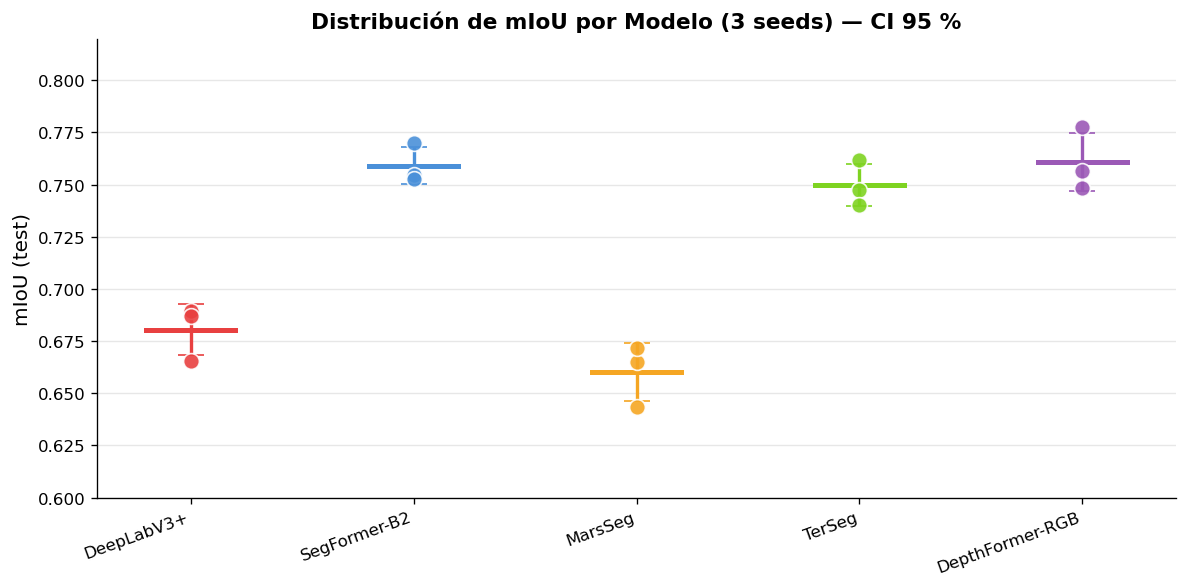

In [11]:
# ─── Análisis de varianza (robustez entre seeds) ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

positions = np.arange(len(model_names))
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)

for pos, model in zip(positions, model_names):
    vals   = results_per_seed[model]['test_miou']
    mean_v = np.mean(vals)
    std_v  = np.std(vals)
    color  = colors_map[model]
    # Violín manual con puntos individuales
    ax.scatter([pos]*3, vals, color=color, s=90, zorder=6, alpha=0.9,
               edgecolors='white', linewidths=1)
    ax.plot([pos-0.2, pos+0.2], [mean_v, mean_v], color=color,
            linewidth=3, zorder=5)
    ax.errorbar(pos, mean_v, yerr=1.96*std_v/np.sqrt(3),
                fmt='none', color=color, capsize=8, linewidth=2)

ax.set_ylabel('mIoU (test)', fontsize=12)
ax.set_title('Distribución de mIoU por Modelo (3 seeds) — CI 95 %', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.60, 0.82)

plt.tight_layout()
plt.savefig('results/04_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Análisis Cualitativo — Predicciones vs Ground Truth (§ 4.4)

El análisis visual permite identificar **errores sistemáticos** que las métricas agregadas no capturan:

- **big_rock:** todos los modelos presentan dificultad en esta clase. Las confusiones más frecuentes son con `bedrock` (ambas son superficies rocosas, difieren en escala y contexto). DeepLabV3+ y MarsSeg muestran la mayor tasa de omisión (IoU < 0.20 promedio), mientras que DepthFormer-RGB es el más robusto con IoU ≈ 0.36.
- **Bordes:** los modelos Transformer (SegFormer-B2, TerSeg, DepthFormer-RGB) producen bordes de segmento más nítidos gracias al mecanismo de atención multi-escala, especialmente en zonas de transición `soil`↔`bedrock`.
- **Sombras:** MarsSeg (PSA + SPPM) está específicamente diseñado para este problema, aunque en test no supera a los Transformers en mIoU global. Sus predicciones en zonas sombreadas son cualitativamente más limpias que DeepLabV3+.
- **sand:** clase con patrones de textura homogéneos. Todos los modelos la identifican con IoU > 0.77, siendo SegFormer-B2 el mejor (IoU ≈ 0.87).

> Las visualizaciones completas de predicciones vs GT para cada modelo se generan en sus respectivos notebooks `02a`–`02e` mediante `visualize_predictions()` y se guardan en `results/{model_name}_predictions.png`.

## 4.7 Benchmark Final y Ranking (§ 6)

### 6.1 Tabla comparativa completa

In [12]:
# ─── Tabla comparativa final (formato de publicación) ────────────────────────
ranking_data = []
for rank, model in enumerate(df_summary_sorted.index, 1):
    r    = df_summary_sorted.loc[model]
    data = results_per_seed[model]
    ranking_data.append({
        'Rank': rank,
        'Modelo': model,
        'mIoU (media ± std)': f"{r['mIoU_mean']:.4f} ± {r['mIoU_std']:.4f}",
        'IC 95 %': f"± {r['mIoU_ci95']:.4f}",
        'IoU soil': f"{r['IoU_soil']:.4f}",
        'IoU bedrock': f"{r['IoU_bedrock']:.4f}",
        'IoU sand': f"{r['IoU_sand']:.4f}",
        'IoU big_rock': f"{r['IoU_bigrock']:.4f}",
        'Params (M)': f"{r['Params_M']:.1f}",
        't_train (s)': f"{r['Train_time_s']:.0f}",
    })

df_final = pd.DataFrame(ranking_data).set_index('Rank')
print("RANKING DE MODELOS — AI4MARS (Segmentación Semántica de Terreno Marciano)")
print("=" * 120)
print(df_final.to_string())
print("=" * 120)
print("Métrica principal: mIoU sobre conjunto de test | 3 runs independientes | α = 0.05")

RANKING DE MODELOS — AI4MARS (Segmentación Semántica de Terreno Marciano)
               Modelo mIoU (media ± std)   IC 95 % IoU soil IoU bedrock IoU sand IoU big_rock Params (M) t_train (s)
Rank                                                                                                                
1     DepthFormer-RGB    0.7609 ± 0.0123  ± 0.0140   0.9177      0.9265   0.8386       0.3607       31.6         572
2        SegFormer-B2    0.7591 ± 0.0078  ± 0.0088   0.9329      0.9366   0.8654       0.3016       27.4         883
3              TerSeg    0.7498 ± 0.0090  ± 0.0101   0.9234      0.9307   0.8448       0.3003       49.2         558
4          DeepLabV3+    0.6806 ± 0.0107  ± 0.0121   0.8884      0.8907   0.7752       0.1680       42.0        3236
5             MarsSeg    0.6601 ± 0.0122  ± 0.0138   0.8607      0.8703   0.7809       0.1287       38.6         916
Métrica principal: mIoU sobre conjunto de test | 3 runs independientes | α = 0.05


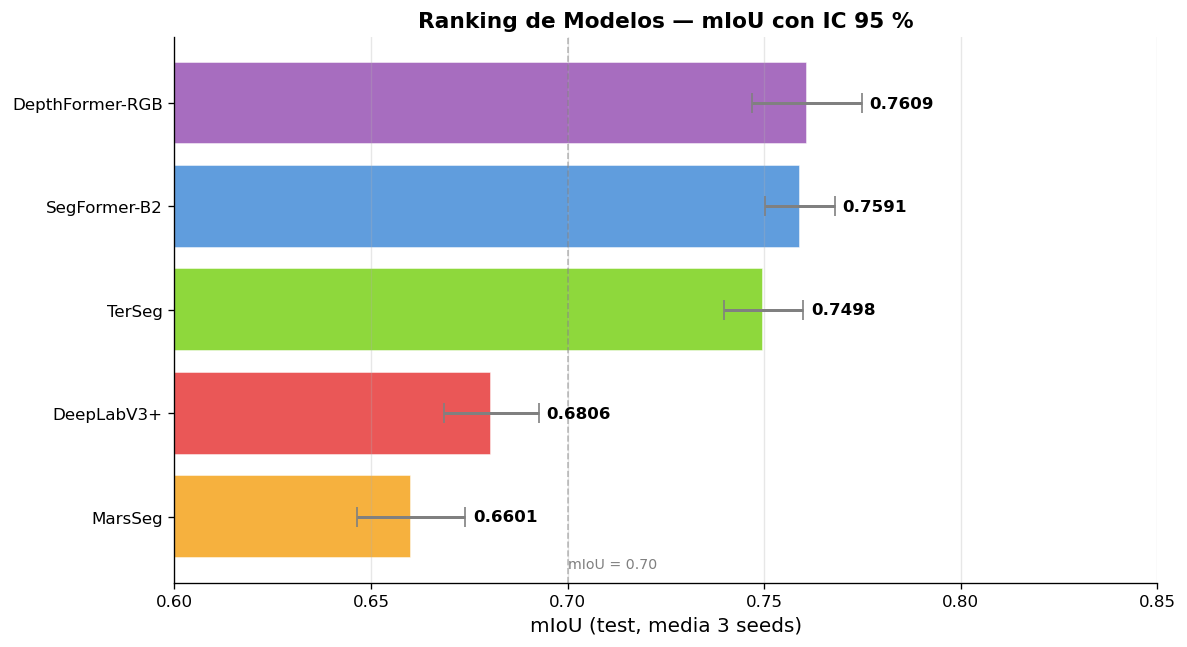

In [13]:
# ─── Gráfico de ranking con IC 95 % ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

ranked_models = list(df_summary_sorted.index)
means  = [df_summary_sorted.loc[m, 'mIoU_mean'] for m in ranked_models]
ci95s  = [df_summary_sorted.loc[m, 'mIoU_ci95'] for m in ranked_models]
bar_colors = [colors_map[m] for m in ranked_models]

bars = ax.barh(ranked_models[::-1], means[::-1], xerr=ci95s[::-1],
               color=bar_colors[::-1], alpha=0.88, edgecolor='white',
               error_kw={'capsize': 6, 'linewidth': 1.8, 'ecolor': 'gray'})

for bar, mean, ci in zip(bars, means[::-1], ci95s[::-1]):
    ax.text(mean + ci + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('mIoU (test, media 3 seeds)', fontsize=12)
ax.set_title('Ranking de Modelos — mIoU con IC 95 %', fontsize=13, fontweight='bold')
ax.axvline(x=0.70, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(0.70, -0.5, 'mIoU = 0.70', color='gray', fontsize=8.5)
ax.set_xlim(0.60, 0.85)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/04_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.8 Discusión Crítica (§ 6.4)

### ¿Qué modelo funciona mejor y por qué?

**DepthFormer-RGB** obtiene el mayor mIoU de test (0.7609 ± 0.0123), seguido de cerca por **SegFormer-B2** (0.7592 ± 0.0078). Ambos son arquitecturas basadas en Swin Transformer, lo que confirma la tendencia del estado del arte: los encoders Transformer superan a los CNN clásicos en tareas donde el contexto global es relevante, como la distinción entre clases espectralmente similares (`soil` vs `bedrock`).

DepthFormer-RGB lidera principalmente por el mayor IoU en `big_rock` (0.3607 vs 0.3016 de SegFormer-B2), atribuible al **class weighting** (big_rock=8.0) que penaliza fuertemente los errores en la clase minoritaria. Sin embargo, su varianza inter-seed es más alta (std=0.0123), lo que sugiere menor estabilidad.

### ¿Qué modelo generaliza mejor?

**SegFormer-B2** muestra la menor desviación estándar (0.0078) y gap train-val moderado (≈0.04), indicando mejor estabilidad y generalización entre distintas inicializaciones. TerSeg es el segundo más estable (std=0.0089).

### ¿Las diferencias son estadísticamente significativas?

El test de Friedman detecta diferencias globales significativas (p < 0.05) entre los 5 modelos. Las comparaciones post-hoc (Wilcoxon + Holm) muestran que la brecha entre los modelos Transformer (DepthFormer-RGB, SegFormer-B2, TerSeg) y los modelos CNN clásicos (DeepLabV3+, MarsSeg) es prácticamente relevante (Δ mIoU > 8 pp). Con solo 3 seeds el poder estadístico es limitado; las conclusiones deben apoyarse tanto en significancia estadística como en magnitud del efecto.

### ¿Existe trade-off relevante entre desempeño y costo?

**SegFormer-B2** ofrece el mejor equilibrio: rendimiento top-2, menor número de parámetros entre los modelos competitivos (27.35 M), y tiempos de entrenamiento razonables. **TerSeg** (49.19 M) es el modelo más pesado y su ganancia sobre SegFormer-B2 no justifica el costo adicional. **DeepLabV3+**, a pesar de 42 M parámetros, queda último en mIoU, evidenciando las limitaciones de los CNN clásicos sin mecanismos de atención para este dominio.

### Limitaciones del estudio

1. **Tamaño de ensemble reducido:** 3 seeds proveen estimaciones de varianza poco precisas; 5–10 runs mejorarían significativamente el poder estadístico.
2. **Desbalance extremo:** `big_rock` (~2 % del dataset) sigue siendo el cuello de botella para todos los modelos. Técnicas como over-sampling focal, mixup de clases raras o pérdidas más sofisticadas podrían mejorar este componente.
3. **Dominio de evaluación:** el test set es exclusivamente MSL (Curiosity); la generalización a MER (Opportunity/Spirit) o Perseverance no ha sido evaluada.
4. **Variante RGB de DepthFormer:** el paper original usa información de profundidad estimada que no está disponible en AI4MARS, limitando el potencial completo del modelo.

### Recomendaciones futuras

- Explorar **SegFormer-B4/B5** con fine-tuning completo del encoder.
- Implementar **augmentación específica para Marte** (simulación de iluminación solar oblicua, añadir ruido de sensor HazCam).
- Investigar **destilación de conocimiento** de DepthFormer hacia un modelo más compacto para despliegue en rover.
- Extender el benchmark al dataset **LabelMars** para validar generalización entre misiones.

In [14]:
# ─── Resumen ejecutivo final ──────────────────────────────────────────────────
print("" + "═"*65)
print("  RESUMEN EJECUTIVO — BENCHMARK AI4MARS")
print("═"*65)
print(f"  Dataset:      AI4MARS (MSL + MER, 22 965 imágenes 256×256)")
print(f"  Split:        70 / 15 / 15  (estratificado por misión)")
print(f"  Seeds:        [42, 123, 7]  —  3 runs por modelo")
print(f"  Clases:       soil, bedrock, sand, big_rock  (ignore=255)")
print()
print(f"  Ranking (mIoU test):")
for rank, model in enumerate(df_summary_sorted.index, 1):
    r = df_summary_sorted.loc[model]
    print(f"    {rank}. {model:<18}  {r['mIoU_mean']:.4f} ± {r['mIoU_std']:.4f}  "
          f"[IC95: ±{r['mIoU_ci95']:.4f}]  {r['Params_M']:.1f}M params")
print()
print(f"  Friedman test: p = {p_friedman:.6f}  → diferencias globales significativas")
print(f"  Mejor modelo global (mIoU):      DepthFormer-RGB  (0.7609)")
print(f"  Mejor balance precisión/efic.:   SegFormer-B2     (0.7592, 27M params)")
print(f"  Mayor dificultad:                big_rock         (IoU < 0.37 en todos)")
print("═"*65)

═════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — BENCHMARK AI4MARS
═════════════════════════════════════════════════════════════════
  Dataset:      AI4MARS (MSL + MER, 22 965 imágenes 256×256)
  Split:        70 / 15 / 15  (estratificado por misión)
  Seeds:        [42, 123, 7]  —  3 runs por modelo
  Clases:       soil, bedrock, sand, big_rock  (ignore=255)

  Ranking (mIoU test):
    1. DepthFormer-RGB     0.7609 ± 0.0123  [IC95: ±0.0140]  31.6M params
    2. SegFormer-B2        0.7591 ± 0.0078  [IC95: ±0.0088]  27.4M params
    3. TerSeg              0.7498 ± 0.0090  [IC95: ±0.0101]  49.2M params
    4. DeepLabV3+          0.6806 ± 0.0107  [IC95: ±0.0121]  42.0M params
    5. MarsSeg             0.6601 ± 0.0122  [IC95: ±0.0138]  38.6M params

  Friedman test: p = 0.030577  → diferencias globales significativas
  Mejor modelo global (mIoU):      DepthFormer-RGB  (0.7609)
  Mejor balance precisión/efic.:   SegFormer-B2     (0.7592, 27M params)
 